# Customer Segmentation using PCA

This project applies Principal Component Analysis (PCA) to reduce dimensionality and visualize customer behavior patterns.

In [1]:
# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

%matplotlib inline

# Display formatting
from IPython.core.display import HTML
HTML("""
<style>
.dataframe table, .dataframe th, .dataframe td { font-size: 14px; }
div.output_scroll { overflow-x: auto; }
</style>
""")

import os
os.environ["OMP_NUM_THREADS"] = "4"


### Loading the Dataset


In [2]:
mall = pd.read_csv("mall_customers.csv")

mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
mall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [4]:
mall.isna().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

We inspect data structure and missing values before processing.

## Data Cleaning

In [5]:
mall.columns = [
    "customer_id",
    "gender",
    "age",
    "annual_income",
    "spending_score"
]

In [6]:
mall = mall.drop("customer_id", axis=1)
mall.head()

,gender,age,annual_income,spending_score
0,M,39.0,59.9,58.0
1,M,34.0,48.4,37.0
2,F,40.0,70.5,26.0
3,F,47.0,81.1,30.0
4,F,33.0,42.1,58.0


In [7]:
mall["gender"] = mall["gender"].fillna(mall["gender"].mode()[0])

mall["age"] = mall["age"].fillna(mall["age"].median())

mall["annual_income"] = mall["annual_income"].fillna(mall["annual_income"].median())

mall["spending_score"] = mall["spending_score"].fillna(mall["spending_score"].median())

## Exploratory Data Analysis

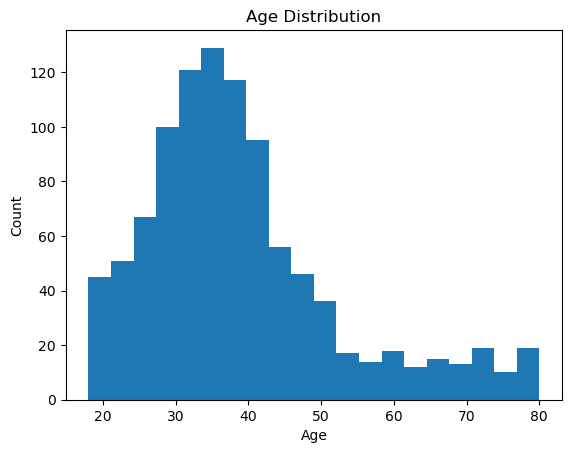

In [8]:
plt.hist(mall["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

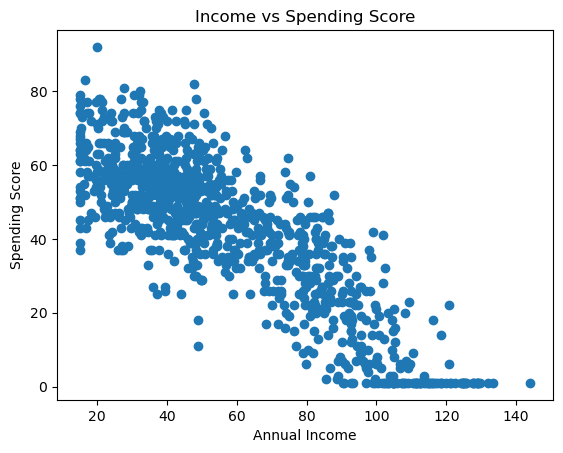

In [9]:
plt.scatter(mall["annual_income"], mall["spending_score"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

## Feature Selection

In [10]:
X = mall[["age", "annual_income", "spending_score"]]
X.head()

,age,annual_income,spending_score
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.0061401 ,  0.09745644,  0.76510194],
       [-0.36825649, -0.3051838 , -0.28311966],
       [ 0.08101942,  0.46858571, -0.83218813],
       [ 0.60517466,  0.83971497, -0.63252687],
       [-0.44313581, -0.52576062,  0.76510194]])

PCA is sensitive to feature scales, so standardization is applied before dimensionality reduction.

## Apply PCA

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [13]:
X_pca[:5]

array([[-0.3716141 ,  0.66930681],
       [-0.23299693, -0.50406887],
       [ 0.7910725 , -0.47860401],
       [ 1.20057987,  0.04793744],
       [-0.99758016,  0.24665504]])

In [14]:
pca.explained_variance_ratio_

array([0.91000949, 0.06324881])

The first principal component explains approximately 91% of the total variance, while the second explains about 6%.

Together, the two principal components retain approximately 97% of the information from the original dataset.

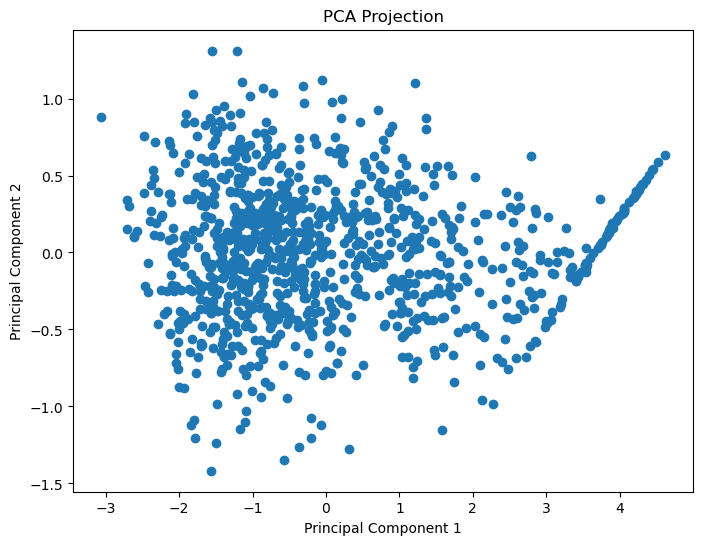

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")

plt.show()

## Insights

- PCA successfully reduced the dataset from 3 features to 2 principal components.
- The first principal component captured most of the variance in the data.
- Approximately 97% of the original information was retained after dimensionality reduction.
- No clearly separated groups were observed in the PCA projection.

## Conclusion

PCA effectively reduced dimensionality while preserving most of the information in the dataset.

The first principal component explained the majority of the variance, indicating a dominant underlying pattern in customer behavior.

Although PCA improved visualization and reduced complexity, it did not reveal clearly separated customer groups, suggesting that clustering algorithms are still required for segmentation tasks.